# Within-dataset pooled subjects generalisation — Figures


In [23]:
# DEPENDENCIES

import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [24]:
# SET-UP
SUBJECTS = helper_functions.fuglsang_get_subjects()
test_percent = 0.3
num_testing_subjects = int(len(SUBJECTS)*(test_percent))
print(num_testing_subjects)
training_subjects = SUBJECTS[:-num_testing_subjects]
testing_subjects = SUBJECTS[len(SUBJECTS)-num_testing_subjects::]

# Plot style
helper_functions.set_plot_style()

5


## Pooled subjects TRFs

## Figure 1 — Combined Visual inspection of TRF AAD and reconstruction accuracy

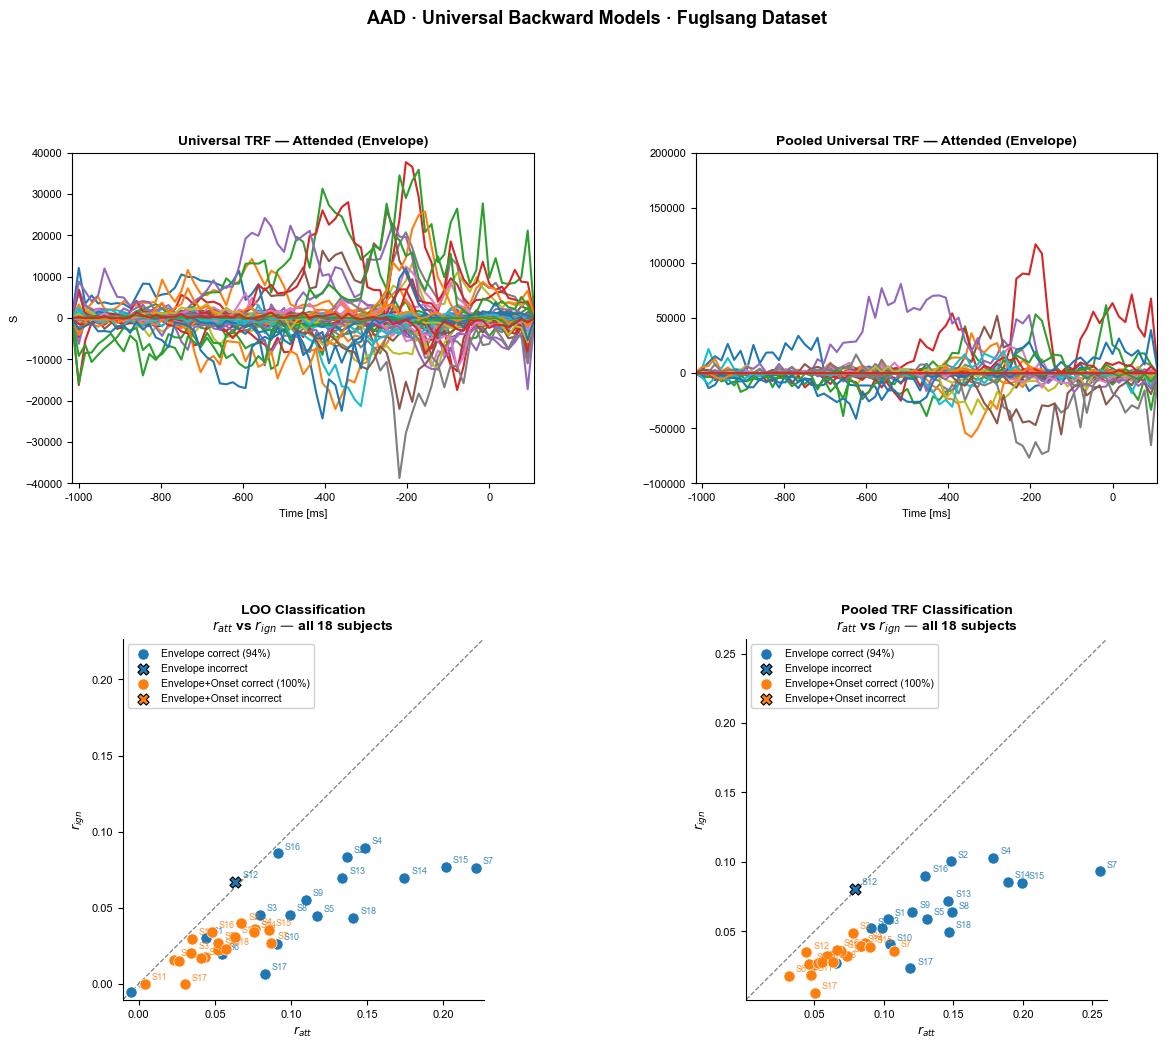

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import eelbrain

# ── LOO data (pre-computed) ────────────────────────────────────────────────────

loocv_per_subject = {
    'Envelope': {
        'attended': [0.04413523033501584, 0.1369588602974286, 0.07965207469240071,
                     0.14842501829433113, 0.11688663320308847, 0.05481776718163736,
                     0.2216774610930428, 0.09940407744555617, 0.1098311589313232,
                     0.09081574710981122, -0.005116863582976209, 0.06352450998289015,
                     0.13379659003397432, 0.17460300414321542, 0.20190296248328157,
                     0.09134597923211513, 0.08296435912111645, 0.14100396482348404],
        'ignored':  [0.030333030980150534, 0.0831455033011503, 0.045141973001512445,
                     0.08954384112161905, 0.044592710454143585, 0.019776256814218185,
                     0.07596553377464961, 0.04513639305514011, 0.05520917479539315,
                     0.026080074930551672, -0.005423540251799059, 0.06696649492361649,
                     0.06982537099675502, 0.06959357047877393, 0.07660122202229491,
                     0.08575087177872047, 0.006622320541481853, 0.04307978646967332],
    },
    'Onset': {
        'attended': [0.023056260145546778, 0.06751520922256926, 0.03460901766030194,
                     0.07636267523691982, 0.04370618358583527, 0.026344983830439303,
                     0.08685621147796718, 0.05221021328227544, 0.051783529251824084,
                     0.04118701373991802, 0.003992862146395594, 0.03470881831739575,
                     0.06306463859565246, 0.07566694911482105, 0.08558129196692113,
                     0.0478311889720087, 0.030413294059649158, 0.05757366656570074],
        'ignored':  [0.015547000017338723, 0.03963855389161348, 0.020490368898056492,
                     0.03631853959882594, 0.017735093625816108, 0.014835570312827562,
                     0.026622897159700402, 0.022399727223866017, 0.026628475126278583,
                     0.016623757680403983, 0.00017203273018956845, 0.029510828195825147,
                     0.030677702270567046, 0.034037648342926434, 0.03540854071777432,
                     0.03388222825945703, -0.00042903175630252773, 0.022691377574025378],
    },
}

# ── pooled scatter data ────────────────────────────────────────────────────────

def compute_pooled_scatter_data(predictor, attention_att, attention_ign, subjects):
    """
    Uses the pooled universal TRF to reconstruct envelopes for ALL subjects.
    """
    att_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, attention_att, MODEL_TYPE.BACKWARD, False
    )
    ign_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, attention_ign, MODEL_TYPE.BACKWARD, False
    )

    # Load pooled TRFs
    pooled_att_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, attention_att, MODEL_TYPE.BACKWARD
    )
    pooled_ign_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, attention_ign, MODEL_TYPE.BACKWARD
    )
    trf_att = eelbrain.load.unpickle(FUGLSANG_TRF_DIR / f'pooled_universal_{pooled_att_name}_trf').h_scaled
    trf_ign = eelbrain.load.unpickle(FUGLSANG_TRF_DIR / f'pooled_universal_{pooled_ign_name}_trf').h_scaled

    r_att_list, r_ign_list = [], []

    for subject in subjects:
        eeg = eelbrain.load.unpickle(
            FUGLSANG_EEG_DIR / subject / f'{subject}_eeg.pickle'
        )
        att_stim = eelbrain.load.unpickle(
            FUGLSANG_PREDICTOR_DIR / subject / f'{att_name.split("backward_")[1]}_concat.pickle'
        )
        ign_stim = eelbrain.load.unpickle(
            FUGLSANG_PREDICTOR_DIR / subject / f'{ign_name.split("backward_")[1]}_concat.pickle'
        )

        pred_att = eelbrain.convolve(trf_att, eeg).x
        pred_ign = eelbrain.convolve(trf_ign, eeg).x

        r_att_list.append(np.corrcoef(pred_att, att_stim.x)[0, 1])
        r_ign_list.append(np.corrcoef(pred_ign, ign_stim.x)[0, 1])

    r_att = np.array(r_att_list)
    r_ign = np.array(r_ign_list)
    acc   = np.mean(r_att > r_ign)

    return r_att, r_ign, acc


# ── scatter plotting helper ────────────────────────────────────────────────────

def plot_scatter_panel(ax, subjects,
                       r_att_env, r_ign_env, acc_env,
                       r_att_onset, r_ign_onset, acc_onset,
                       color_env='tab:blue', color_onset='tab:orange'):
    """
    Plots both Envelope and Envelope+Onset on one scatter axes.
    Correct = circle, Incorrect = X marker.
    """
    for r_att, r_ign, acc, color, label in [
        (r_att_env,   r_ign_env,   acc_env,   color_env,   'Envelope'),
        (r_att_onset, r_ign_onset, acc_onset, color_onset, 'Envelope+Onset'),
    ]:
        correct  = r_att > r_ign
        incorrect = ~correct

        ax.scatter(r_att[correct], r_ign[correct],
                   color=color, edgecolors='white', linewidths=0.5,
                   s=65, zorder=3,
                   label=f'{label} correct ({acc:.0%})')
        ax.scatter(r_att[incorrect], r_ign[incorrect],
                   color=color, edgecolors='black', linewidths=0.8,
                   s=65, zorder=3, marker='X',
                   label=f'{label} incorrect')

        # subject labels
        for s, x, y in zip(subjects, r_att, r_ign):
            ax.annotate(s, (x, y), textcoords='offset points', xytext=(5, 3),
                        fontsize=6.5, color=color, alpha=0.85)

    # unity diagonal
    all_r = np.concatenate([r_att_env, r_ign_env, r_att_onset, r_ign_onset])
    lims  = [all_r.min() - 0.005, all_r.max() + 0.005]
    ax.plot(lims, lims, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

    ax.set_xlabel('$r_{att}$', fontsize=9)
    ax.set_ylabel('$r_{ign}$', fontsize=9)
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)


# ── load TRFs ─────────────────────────────────────────────────────────────────

att_name_env = helper_functions.get_trf_model_name(
    DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE,
    ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False
)
universal_trf = eelbrain.load.unpickle(
    FUGLSANG_TRF_DIR / f'universal-{att_name_env}.pickle'
)

pooled_trf_name = helper_functions.get_trf_model_name(
    DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE,
    ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD
)
pooled_trf = eelbrain.load.unpickle(
    FUGLSANG_TRF_DIR / f'pooled_universal_{pooled_trf_name}_trf'
).h_scaled

# ── compute pooled scatter data (all 18 subjects) ─────────────────────────────

r_att_pool_env,   r_ign_pool_env,   acc_pool_env   = compute_pooled_scatter_data(
    PREDICTOR_TYPE.ENVELOPE,
    ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED,
    SUBJECTS,
)
r_att_pool_onset, r_ign_pool_onset, acc_pool_onset = compute_pooled_scatter_data(
    PREDICTOR_TYPE.ENVELOPE_ONSET,
    ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED,
    SUBJECTS,
)

# ── LOO arrays (all 18 subjects, pre-computed) ────────────────────────────────

r_att_loo_env   = np.array(loocv_per_subject['Envelope']['attended'])
r_ign_loo_env   = np.array(loocv_per_subject['Envelope']['ignored'])
acc_loo_env     = np.mean(r_att_loo_env > r_ign_loo_env)

r_att_loo_onset = np.array(loocv_per_subject['Onset']['attended'])
r_ign_loo_onset = np.array(loocv_per_subject['Onset']['ignored'])
acc_loo_onset   = np.mean(r_att_loo_onset > r_ign_loo_onset)

# ── build figure ───────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.1, 1.2],
    hspace=0.45,
    wspace=0.35,
)

# ── Row 0: TRF butterflies ────────────────────────────────────────────────────

ax_univ = fig.add_subplot(gs[0, 0])
ax_pool = fig.add_subplot(gs[0, 1])

eelbrain.plot.Butterfly(universal_trf, axes=ax_univ, show=False)
ax_univ.set_title('Universal TRF — Attended (Envelope)', fontsize=10, fontweight='bold')

eelbrain.plot.Butterfly(pooled_trf, axes=ax_pool, show=False)
ax_pool.set_title('Pooled Universal TRF — Attended (Envelope)', fontsize=10, fontweight='bold')

# ── Row 1: scatter panels ─────────────────────────────────────────────────────

ax_loo  = fig.add_subplot(gs[1, 0])
ax_pool_sc = fig.add_subplot(gs[1, 1])

plot_scatter_panel(
    ax_loo, SUBJECTS,
    r_att_loo_env,  r_ign_loo_env,  acc_loo_env,
    r_att_loo_onset, r_ign_loo_onset, acc_loo_onset,
)
ax_loo.set_title(
    'LOO Classification\n$r_{att}$ vs $r_{ign}$ — all 18 subjects',
    fontsize=10, fontweight='bold'
)

plot_scatter_panel(
    ax_pool_sc, SUBJECTS,
    r_att_pool_env,   r_ign_pool_env,   acc_pool_env,
    r_att_pool_onset, r_ign_pool_onset, acc_pool_onset,
)
ax_pool_sc.set_title(
    'Pooled TRF Classification\n$r_{att}$ vs $r_{ign}$ — all 18 subjects',
    fontsize=10, fontweight='bold'
)

# ── finish ────────────────────────────────────────────────────────────────────

fig.suptitle(
    'AAD · Universal Backward Models · Fuglsang Dataset',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('aad_combined_figure.png', dpi=150, bbox_inches='tight')
plt.show()